# Multivariate t (Student) Distribution

`MultivariateT(mean, cov, df)` generalizes Student's t-distribution to several dimensions -- the heavy-tailed counterpart of the `MultivariateNormal`. Each draw is a vector of correlated values; `mean` is the location, `cov` is the scale (shape) matrix, and `df` sets the tail weight.

In [1]:
from symbulate import *

## Draw a value

Each draw is a vector, one entry per dimension.

In [2]:
MultivariateT(mean=[0, 0], cov=[[1, 0], [0, 1]], df=5).draw()

(0.2715990788985203, 0.803055110968229)

## Simulate

Every simulated value is a 2-dimensional vector.

In [3]:
MultivariateT(mean=[0, 0], cov=[[1, 0], [0, 1]], df=5).sim(1000)

0,"(-2.8970580173371303, 1.0438497437513785)"
1,"(-0.9434009956047483, 1.6548474800059498)"
2,"(-0.590102707024128, -1.0268883696894295)"
3,"(-0.3025794771823748, 0.43742720363360826)"
4,"(-0.9461418801285979, -1.500992975642687)"
5,"(-0.1818526170227294, -1.5180091323727256)"
6,"(-0.36941563334706934, 0.6904705688706104)"
7,"(-2.0706221292933367, 1.0630319411239042)"
8,"(-1.6427154865639508, 1.719040578014458)"
...,...
999,"(1.0105263227338737, 1.8459336454755764)"


## Mean, variance, and standard deviation

For `df > 2` all the moments exist. `mean()` is the location vector; `var()` and `sd()` are the per-component variances and standard deviations, taken from the diagonal of the covariance (which is inflated relative to the scale matrix by the heavy tails).

In [4]:
X = MultivariateT(mean=[1, 2, 3], cov=[[4, 1, 0.5], [1, 2, -0.3], [0.5, -0.3, 1]], df=5)
X.mean(), X.var(), X.sd()

((1, 2, 3),
 (6.666666666666667, 3.3333333333333335, 1.6666666666666667),
 (2.581988897471611, 1.8257418583505538, 1.2909944487358056))

## Covariance matrix

The `cov` argument is the *scale* matrix, not the covariance. The actual covariance is `df / (df - 2)` times it.

In [5]:
X.cov()

array([[ 6.66666667,  1.66666667,  0.83333333],
       [ 1.66666667,  3.33333333, -0.5       ],
       [ 0.83333333, -0.5       ,  1.66666667]])

## Correlation matrix

The `df / (df - 2)` factor cancels out when the covariance is rescaled to correlations, so the correlation matrix matches that of the scale matrix. Its diagonal is 1.

In [6]:
X.corr()

array([[ 1.        ,  0.35355339,  0.25      ],
       [ 0.35355339,  1.        , -0.21213203],
       [ 0.25      , -0.21213203,  1.        ]])

## Evaluate the pdf at a point

In [7]:
MultivariateT(mean=[0, 0], cov=[[1, 0], [0, 1]], df=5).pdf([0, 0])

np.float64(0.15915494309189535)

## Plot the joint distribution



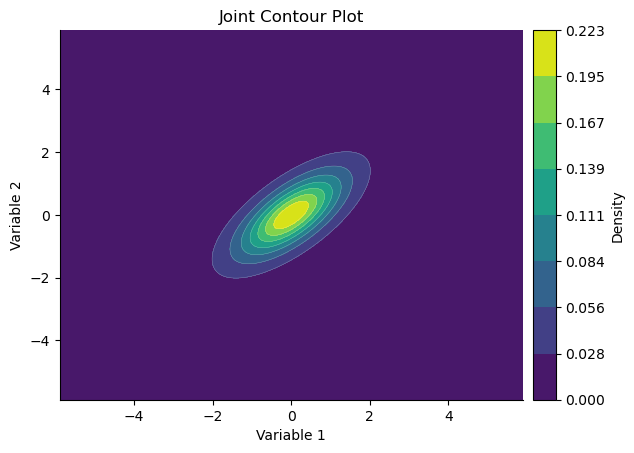

In [8]:
MultivariateT(mean=[0, 0], cov=[[1, 0.7], [0.7, 1]], df=5).plot()

### Contour lines instead of a smooth surface

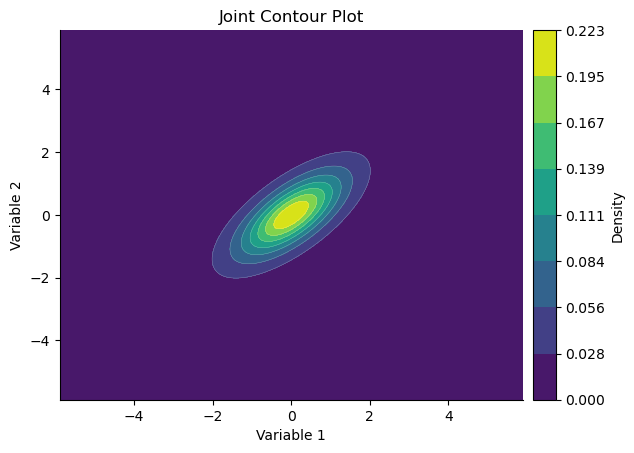

In [9]:
MultivariateT(mean=[0, 0], cov=[[1, 0.7], [0.7, 1]], df=5).plot(contour=True)

### Heavy tails: watch the axis numbers

This is the difference from a multivariate normal. Compare the axis numbers on
the two plots below, not the shapes.

With `df = 2` the plot has to reach past 20 in each direction. With `df = 50`
it only reaches about 3. Heavy tails mean the rare values fall further out, not
that the middle is wider.

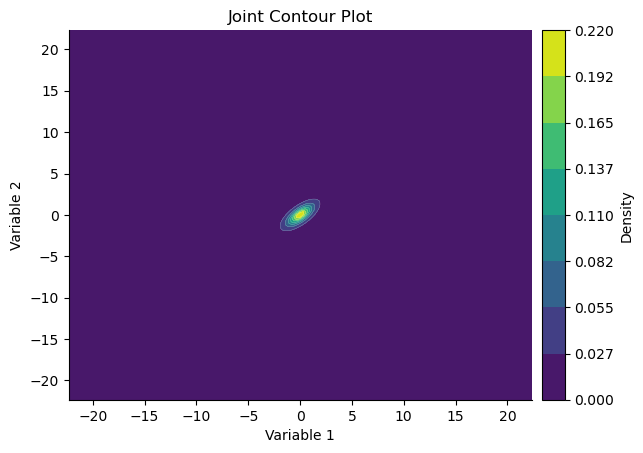

In [10]:
MultivariateT(mean=[0, 0], cov=[[1, 0.7], [0.7, 1]], df=2).plot(contour=True)

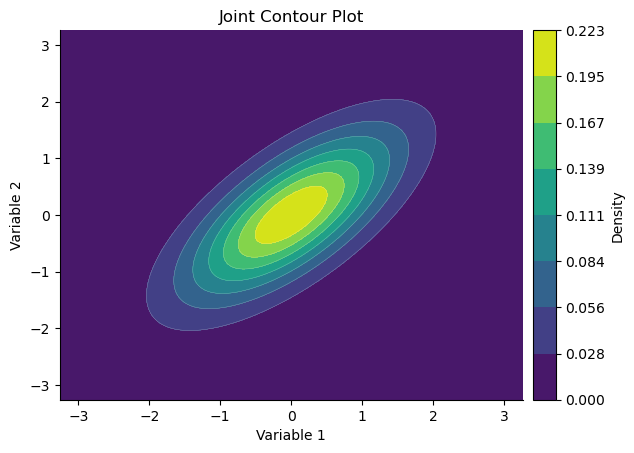

In [11]:
MultivariateT(mean=[0, 0], cov=[[1, 0.7], [0.7, 1]], df=50).plot(contour=True)

## More than two variables: pick a pair with `dims`

With three or more variables there is no single joint plot to show, so `plot()`
asks which two you want. `X.plot()` with no arguments raises an error saying so.

Variables are numbered from 0, so `variables=[0, 1]` means the 1st and 2nd.

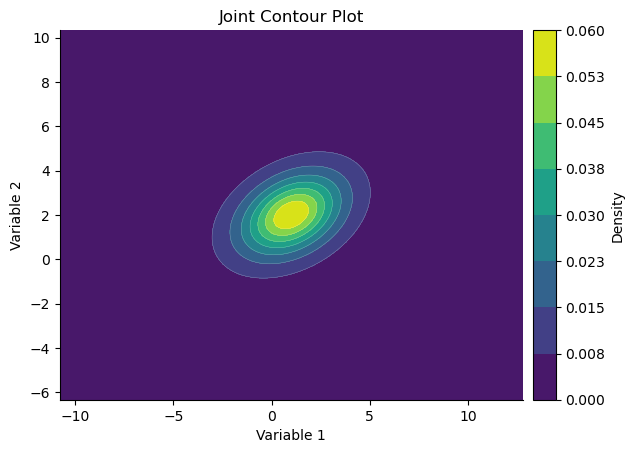

In [12]:
X.plot(variables=(0, 1))

## Every pair at once (the default)

With three or more variables, `.plot()` draws every pair in one grid. The diagonal shows each variable on
its own, which is a shifted and scaled Student's t. Each panel below the
diagonal shows one pair.


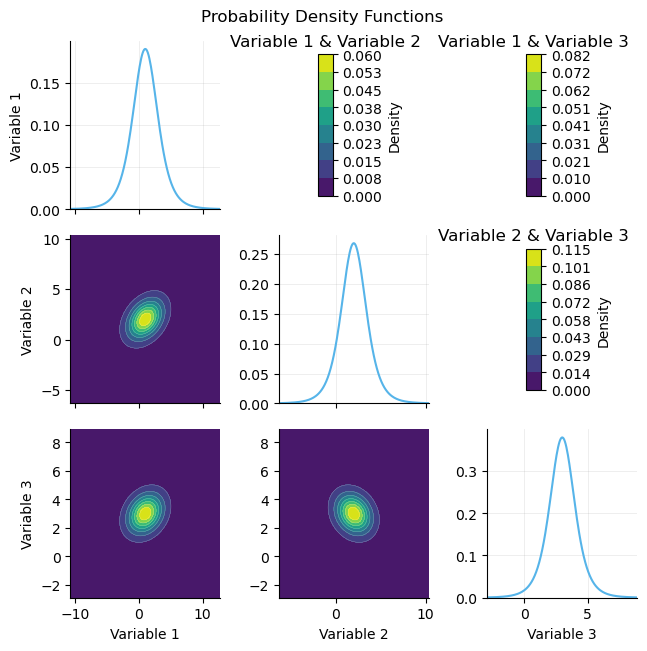

In [13]:
X.plot()